# LACT electronics v2 program-output validation

This notebook only reads outputs produced by `run_corsika_trace` and `run_camera_electronics`. It does not implement a second detector simulation.

In [1]:
# Cell 1 — all user-editable inputs
from pathlib import Path
import json
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle, Polygon

ROOT_PATH = Path('validation/electronics_chain_v2/validation_outputs/gamma_e2e/lact_events.root')
STANDALONE_ROOT = Path('validation/electronics_chain_v2/validation_outputs')
EVENT_ID = 1909
TELESCOPE_ID = 19
PIXEL_ID = None  # None selects the pixel with the largest saturation loss
N_WAVEFORM_PIXELS = 5
CAMERA_CMAP = 'viridis'
PRIMARY_COLOR = '#2878b5'
FIRED_COLOR = '#f28e2b'
LOST_COLOR = '#d62728'

assert ROOT_PATH.exists(), ROOT_PATH
root = uproot.open(ROOT_PATH)
camera = root['camera_pixels'].arrays(library='np')
observations = root['observations'].arrays(library='ak')
waveform_cfg = root['waveform_config'].arrays(library='ak')
waveforms = root['waveforms'].arrays(library='ak')
primary_hits = root['primary_pe_hits'].arrays(library='np')
fired_hits = root['fired_pe_hits'].arrays(library='np')
decisions = root['microcell_decisions'].arrays(library='np')
config_text = str(root['config']['expanded_config_text'].array(library='np')[0])
cfg = dict(line.split('=', 1) for line in config_text.splitlines() if '=' in line)
pixel_to_index = {int(pid): i for i, pid in enumerate(camera['pixel_id'])}

def observation_row(event_id=EVENT_ID, telescope_id=TELESCOPE_ID):
    mask = (np.asarray(observations.event_id) == event_id) & (np.asarray(observations.telescope_id) == telescope_id)
    idx = np.flatnonzero(mask)
    assert len(idx) == 1, (event_id, telescope_id, len(idx))
    return observations[int(idx[0])]

def dense_image(row, field):
    values = np.zeros(len(camera['pixel_id']), dtype=float)
    for pid, value in zip(np.asarray(row.pixel_id), np.asarray(row[field])):
        values[pixel_to_index[int(pid)]] = float(value)
    return values

print(f'ROOT: {ROOT_PATH}')
print(f'camera pixels: {len(camera["pixel_id"])}; event={EVENT_ID}; telescope={TELESCOPE_ID}')
print(f'waveform: {waveform_cfg.waveform_source[0]}, {waveform_cfg.sample_unit[0]}, {waveform_cfg.time_bin_width_ns[0]} ns samples')

ROOT: validation\electronics_chain_v2\validation_outputs\gamma_e2e\lact_events.root
camera pixels: 1664; event=1909; telescope=19
waveform: electronics, mV, 4.0 ns samples


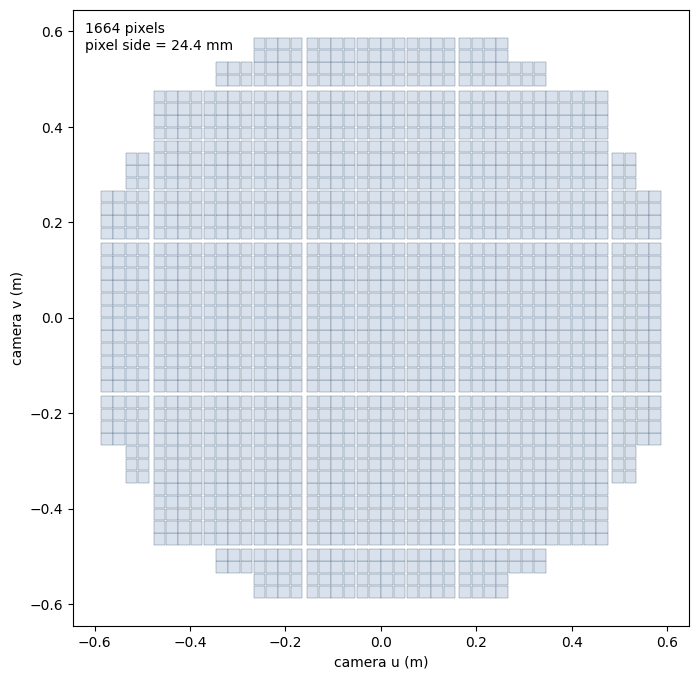

In [2]:
# Cell 2 — the 1664-pixel camera layout read from the ROOT output
fig, ax = plt.subplots(figsize=(8, 8))
patches = [Rectangle((x-s/2, y-s/2), s, s) for x, y, s in zip(camera['x_m'], camera['y_m'], camera['size_m'])]
collection = PatchCollection(patches, facecolor='#d9e2ec', edgecolor='#334e68', linewidth=0.22)
ax.add_collection(collection)
ax.autoscale_view(); ax.set_aspect('equal')
ax.set_xlabel('camera u (m)'); ax.set_ylabel('camera v (m)')
ax.text(0.02, 0.98, f'{len(patches)} pixels\npixel side = {camera["size_m"][0]*1e3:.1f} mm', transform=ax.transAxes, va='top')
plt.show()

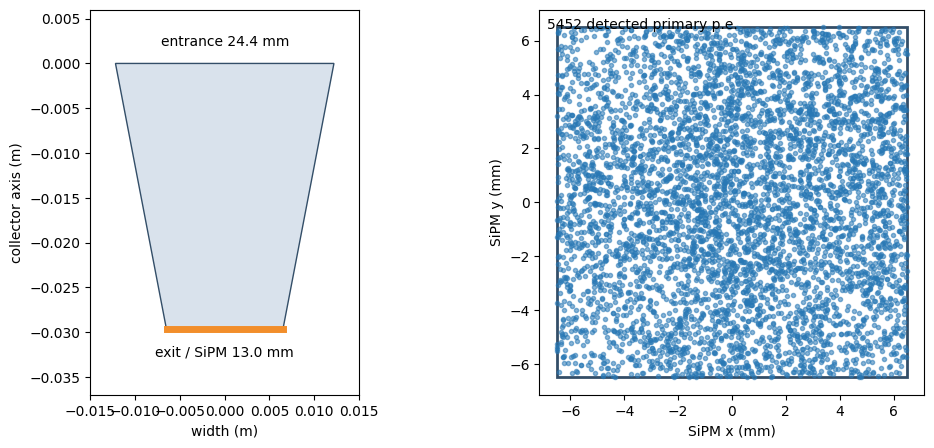

In [3]:
# Cell 3 — collector entrance/exit and SiPM hit positions from program metadata/output
entrance = float(camera['size_m'][0])
exit_size = float(cfg['camera.collector_exit_size_m'])
height = float(cfg['camera.collector_height_m'])
sensor_x = float(cfg['electronics.microcell.sensor_size_x_m'])
sensor_y = float(cfg['electronics.microcell.sensor_size_y_m'])
mask = (primary_hits['event_id'] == EVENT_ID) & (primary_hits['telescope_id'] == TELESCOPE_ID)
hits = {name: values[mask] for name, values in primary_hits.items()}
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))
profile = Polygon([(-entrance/2, 0), (entrance/2, 0), (exit_size/2, -height), (-exit_size/2, -height)], closed=True, facecolor='#d9e2ec', edgecolor='#334e68')
ax0.add_patch(profile); ax0.plot([-sensor_x/2, sensor_x/2], [-height, -height], color=FIRED_COLOR, lw=5)
ax0.text(0, 0.002, f'entrance {entrance*1e3:.1f} mm', ha='center')
ax0.text(0, -height-0.003, f'exit / SiPM {exit_size*1e3:.1f} mm', ha='center')
ax0.set_xlim(-0.015, 0.015); ax0.set_ylim(-0.037, 0.006); ax0.set_aspect('equal'); ax0.set_xlabel('width (m)'); ax0.set_ylabel('collector axis (m)')
ax1.add_patch(Rectangle((-sensor_x/2*1e3, -sensor_y/2*1e3), sensor_x*1e3, sensor_y*1e3, fill=False, lw=2, ec='#334e68'))
ax1.scatter(hits['sensor_x_m']*1e3, hits['sensor_y_m']*1e3, s=9, alpha=0.55, color=PRIMARY_COLOR)
ax1.set_aspect('equal'); ax1.set_xlabel('SiPM x (mm)'); ax1.set_ylabel('SiPM y (mm)')
ax1.text(0.02, 0.98, f'{len(hits["sensor_x_m"])} detected primary p.e.', transform=ax1.transAxes, va='top')
plt.show()

primary=5452 p.e., fired=5446 p.e., loss=6 (0.1101%)


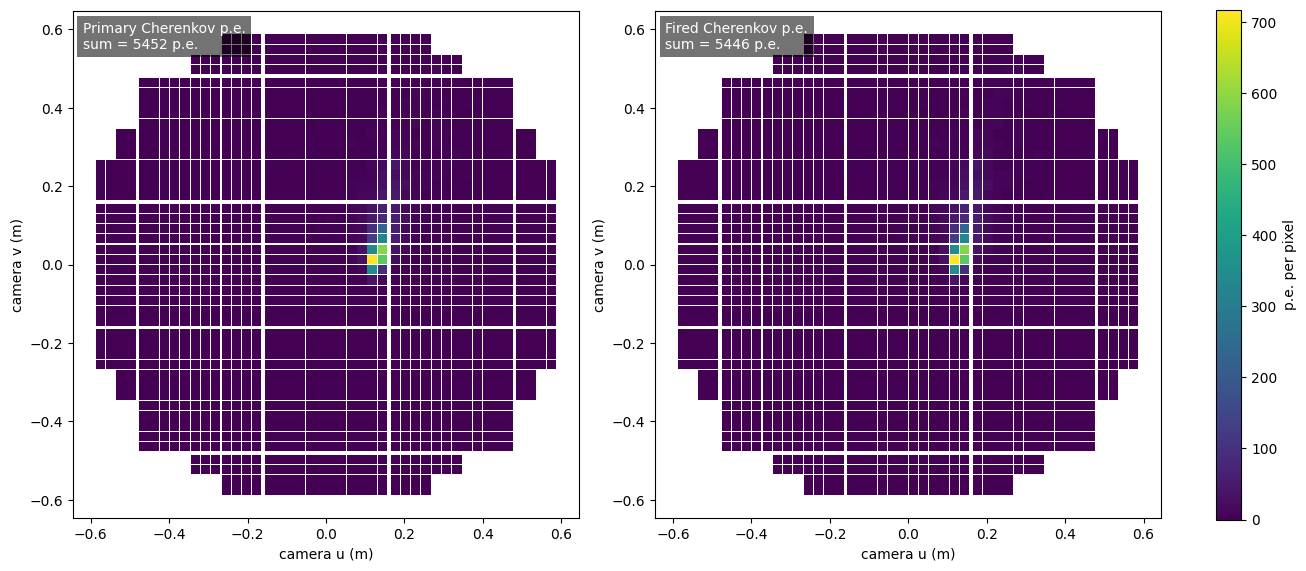

In [4]:
# Cell 4 — pure Cherenkov camera image before and after microcell saturation
row = observation_row()
primary_image = dense_image(row, 'image_cherenkov_pe')
fired_image = dense_image(row, 'image_fired_cherenkov_pe')
vmax = max(primary_image.max(), fired_image.max())
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), constrained_layout=True)
for ax, values, label in zip(axes, [primary_image, fired_image], ['Primary Cherenkov p.e.', 'Fired Cherenkov p.e.']):
    pc = PatchCollection([Rectangle((x-s/2, y-s/2), s, s) for x, y, s in zip(camera['x_m'], camera['y_m'], camera['size_m'])], cmap=CAMERA_CMAP, edgecolor='none')
    pc.set_array(values); pc.set_clim(0, vmax); ax.add_collection(pc); ax.autoscale_view(); ax.set_aspect('equal')
    ax.set_xlabel('camera u (m)'); ax.set_ylabel('camera v (m)')
    ax.text(0.02, 0.98, f'{label}\nsum = {values.sum():.0f} p.e.', transform=ax.transAxes, va='top', color='white', bbox=dict(fc='black', alpha=.55, ec='none'))
fig.colorbar(pc, ax=axes, label='p.e. per pixel')
loss = primary_image.sum() - fired_image.sum()
print(f'primary={primary_image.sum():.0f} p.e., fired={fired_image.sum():.0f} p.e., loss={loss:.0f} ({loss/max(primary_image.sum(),1)*100:.4f}%)')
plt.show()

pixel 827: primary=717, fired=714, rejected=3


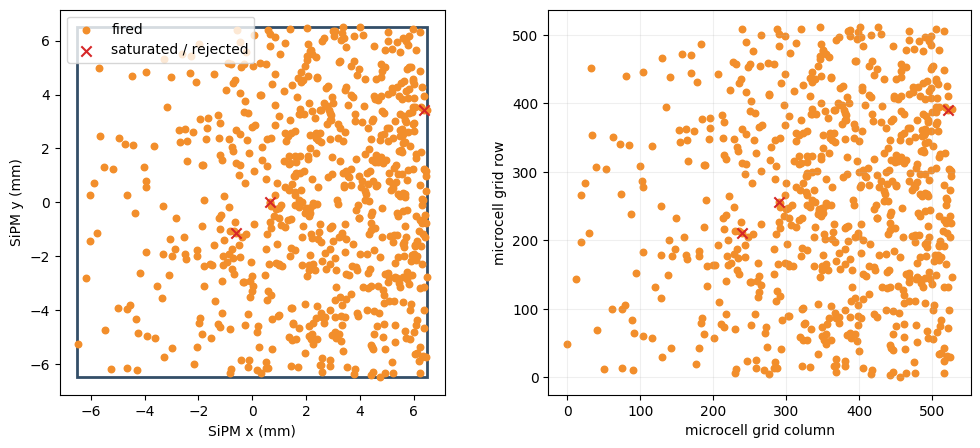

In [5]:
# Cell 5 — exact microcell decisions; rejected photons are marked with x
loss_by_pixel = primary_image - fired_image
selected_pixel = int(camera['pixel_id'][np.argmax(loss_by_pixel)]) if PIXEL_ID is None else int(PIXEL_ID)
m = (decisions['event_id'] == EVENT_ID) & (decisions['telescope_id'] == TELESCOPE_ID) & (decisions['pixel_id'] == selected_pixel)
d = {name: values[m] for name, values in decisions.items()}
fired_mask = d['fired'].astype(bool)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))
ax0.add_patch(Rectangle((-sensor_x/2*1e3, -sensor_y/2*1e3), sensor_x*1e3, sensor_y*1e3, fill=False, lw=2, ec='#334e68'))
ax0.scatter(d['sensor_x_m'][fired_mask]*1e3, d['sensor_y_m'][fired_mask]*1e3, s=22, color=FIRED_COLOR, label='fired')
ax0.scatter(d['sensor_x_m'][~fired_mask]*1e3, d['sensor_y_m'][~fired_mask]*1e3, s=55, marker='x', color=LOST_COLOR, label='saturated / rejected')
ax0.set_aspect('equal'); ax0.set_xlabel('SiPM x (mm)'); ax0.set_ylabel('SiPM y (mm)'); ax0.legend()
ax1.scatter(d['grid_column'][fired_mask], d['grid_row'][fired_mask], s=22, color=FIRED_COLOR)
ax1.scatter(d['grid_column'][~fired_mask], d['grid_row'][~fired_mask], s=55, marker='x', color=LOST_COLOR)
ax1.set_xlabel('microcell grid column'); ax1.set_ylabel('microcell grid row'); ax1.grid(alpha=.2)
print(f'pixel {selected_pixel}: primary={len(fired_mask)}, fired={fired_mask.sum()}, rejected={(~fired_mask).sum()}')
plt.show()

sample spacing = 4.0 ns; samples per pixel = 30


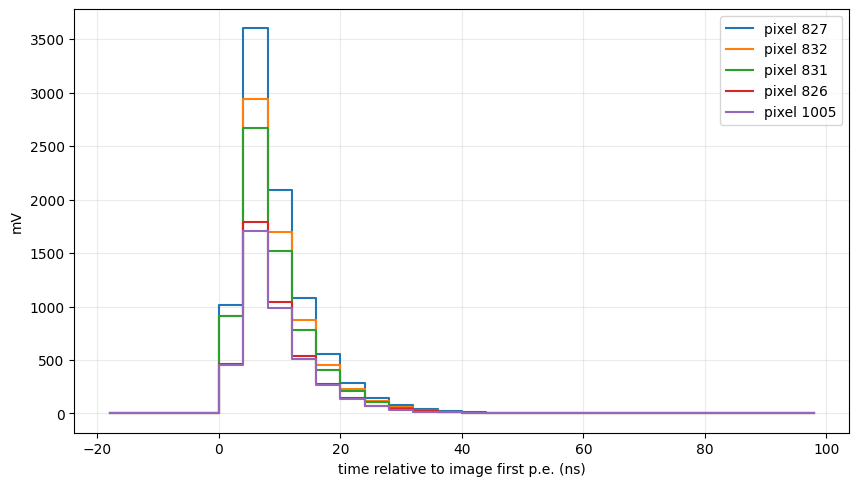

In [6]:
# Cell 6 — 4 ns sampled single-p.e. superposition for several pixels
wmask = (np.asarray(waveforms.event_id) == EVENT_ID) & (np.asarray(waveforms.telescope_id) == TELESCOPE_ID)
widx = int(np.flatnonzero(wmask)[0]); wrow = waveforms[widx]
times = np.asarray(waveform_cfg.time_centers_ns[0], dtype=float)
dense_wf = np.zeros((len(camera['pixel_id']), len(times)), dtype=float)
for pid, tb, value in zip(np.asarray(wrow.pixel_id), np.asarray(wrow.time_bin), np.asarray(wrow.sample_value)):
    dense_wf[pixel_to_index[int(pid)], int(tb)] += float(value)
top = np.argsort(dense_wf.max(axis=1))[-N_WAVEFORM_PIXELS:][::-1]
fig, ax = plt.subplots(figsize=(10, 5.5))
for idx in top:
    ax.step(times, dense_wf[idx], where='mid', label=f'pixel {camera["pixel_id"][idx]}')
ax.set_xlabel('time relative to image first p.e. (ns)'); ax.set_ylabel(str(waveform_cfg.sample_unit[0])); ax.grid(alpha=.25); ax.legend()
print(f'sample spacing = {np.diff(times)[0]:.1f} ns; samples per pixel = {len(times)}')
plt.show()

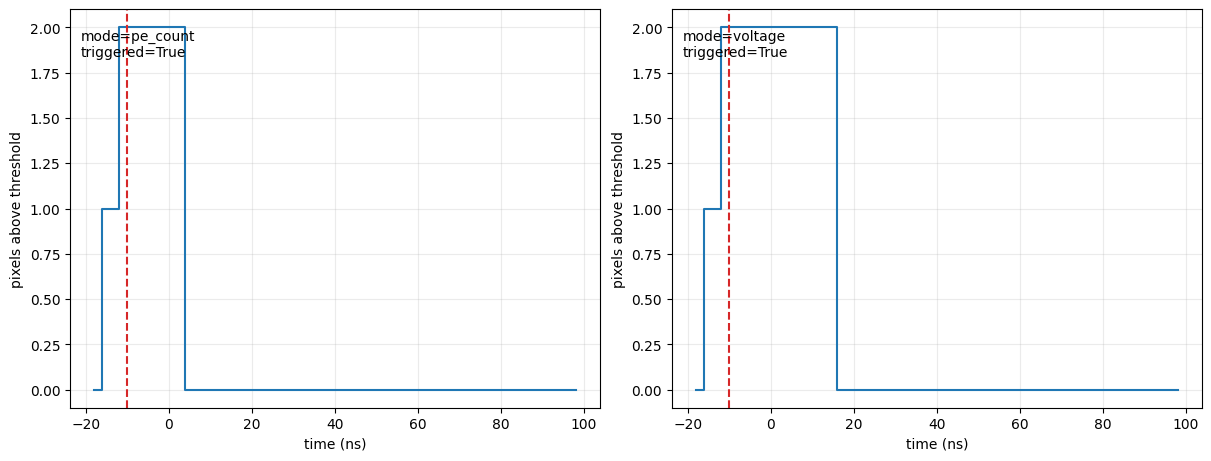

In [7]:
# Cell 7 — standalone p.e.-count and voltage-trigger test outputs
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax, name in zip(axes, ['pe_trigger', 'voltage_trigger']):
    folder = STANDALONE_ROOT / name
    trig = pd.read_csv(folder / 'trigger.csv').iloc[0]
    mult = pd.read_csv(folder / 'trigger_multiplicity.csv')
    ax.step(mult.time_center_ns, mult.pixels_above_threshold, where='mid')
    ax.axvline(trig.trigger_time_ns, ls='--', color=LOST_COLOR)
    ax.set_xlabel('time (ns)'); ax.set_ylabel('pixels above threshold'); ax.grid(alpha=.25)
    ax.text(.02, .95, f'mode={trig["mode"]}\ntriggered={bool(trig["triggered"])}', transform=ax.transAxes, va='top')
plt.show()

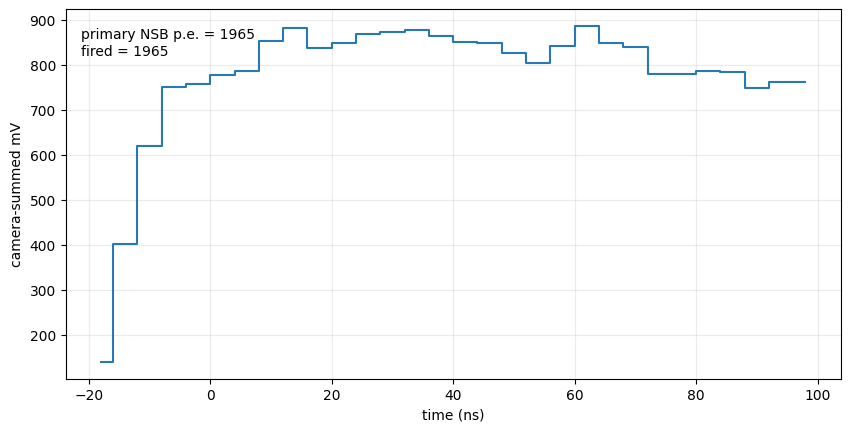

In [8]:
# Cell 8 — independently generated NSB through the same electronics pipeline
nsb_folder = STANDALONE_ROOT / 'nsb_only'
nsb_meta = json.loads((nsb_folder / 'metadata.json').read_text())
nsb_wave = pd.read_csv(nsb_folder / 'waveform.csv')
camera_nsb = nsb_wave.groupby('time_center_ns', as_index=False).sample_value.sum()
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.step(camera_nsb.time_center_ns, camera_nsb.sample_value, where='mid', color=PRIMARY_COLOR)
ax.set_xlabel('time (ns)'); ax.set_ylabel(f'camera-summed {nsb_meta["sample_unit"]}'); ax.grid(alpha=.25)
ax.text(.02, .95, f'primary NSB p.e. = {nsb_meta["n_primary_hits"]}\nfired = {nsb_meta["n_fired_hits"]}', transform=ax.transAxes, va='top')
plt.show()

In [9]:
# Cell 9 — machine-checkable validation summary
all_primary = float(sum(np.sum(np.asarray(v)) for v in observations.image_cherenkov_pe))
all_fired = float(sum(np.sum(np.asarray(v)) for v in observations.image_fired_cherenkov_pe))
summary = pd.DataFrame({
    'check': ['camera pixels', 'gamma telescopes', 'primary Cherenkov p.e.', 'fired Cherenkov p.e.', 'saturation loss', 'nonzero waveform samples', 'sample width (ns)', 'sample unit'],
    'value': [len(camera['pixel_id']), len(observations), all_primary, all_fired, all_primary-all_fired, sum(len(v) for v in waveforms.sample_value), float(waveform_cfg.time_bin_width_ns[0]), str(waveform_cfg.sample_unit[0])]
})
assert len(camera['pixel_id']) == 1664
assert all_fired <= all_primary
assert float(waveform_cfg.time_bin_width_ns[0]) == 4.0
assert str(waveform_cfg.sample_unit[0]) == 'mV'
summary

,check,value
0,camera pixels,1664
1,gamma telescopes,32
2,primary Cherenkov p.e.,12457.0
3,fired Cherenkov p.e.,12451.0
4,saturation loss,6.0
5,nonzero waveform samples,28856
6,sample width (ns),4.0
7,sample unit,mV
